In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.ticker import PercentFormatter

In [2]:
gpt5_base_input_dir = "../assets/data_processed/gpt_5_1"
gpt5mini_base_input_dir = "../assets/data_processed/gpt_5_mini"
gpt5_excel_path = os.path.join(gpt5_base_input_dir, "experiment_summary.xlsx")
gpt5mini_excel_path = os.path.join(gpt5mini_base_input_dir, "experiment_summary.xlsx")

In [3]:
# DEFINICJA KOSZTÓW DANEGO MODELU
MODELS_PRICING = {
    "GPT-5.1": {
        "input_price": 1.25,   # $1.25 za 1M tokenów wejściowych
        "output_price": 10.00  # $10.00 za 1M tokenów wyjściowych
    },
    "GPT-5-Mini": {
        "input_price": 0.25,   # $0.25 za 1M tokenów wejściowych
        "output_price": 2.00   # $2.00 za 1M tokenów wyjściowych
    }
}

In [4]:
# Wczytanie danych gpt
df_gpt = pd.read_excel(gpt5_excel_path)
print(f"Wczytano {len(df_gpt)} wierszy danych dla GPT-5.1")
df_gpt.head()

Wczytano 800 wierszy danych dla GPT-5.1


,architecture,model,problem_id,status,prompt_tokens,completion_tokens,total_tokens,latency_sec,agent_objective_value,ground_truth_answer
0,2-agent,GPT-5.1,nl4opt_test_0,success,1072,1023,2095,14.335,1160.00,1160
1,2-agent,GPT-5.1,nl4opt_test_1,success,2107,2002,4109,28.866,350.00,350
2,2-agent,GPT-5.1,nl4opt_test_2,success,1070,1056,2126,15.979,100.00,100
3,2-agent,GPT-5.1,nl4opt_test_3,success,1062,986,2048,16.282,7.00,7
4,2-agent,GPT-5.1,nl4opt_test_4,success,845,804,1649,11.600,327.66,327.66


In [5]:
# Wczytanie danych gpt_mini
df_mini = pd.read_excel(gpt5mini_excel_path)
print(f"Wczytano {len(df_mini)} wierszy danych dla GPT-5-Mini")
df_mini.head()

Wczytano 799 wierszy danych dla GPT-5-Mini


,architecture,model,problem_id,status,prompt_tokens,completion_tokens,total_tokens,latency_sec,agent_objective_value,ground_truth_answer
0,2-agent,GPT-5-Mini,nl4opt_test_9,success,782,2474,3256,42.061,950.0,950
1,2-agent,GPT-5-Mini,nl4opt_test_17,success,870,2631,3501,45.026,1400.0,1400
2,2-agent,GPT-5-Mini,nl4opt_test_2,success,967,2874,3841,45.321,100.0,100
3,2-agent,GPT-5-Mini,nl4opt_test_1,success,945,2701,3646,46.588,350.0,350
4,2-agent,GPT-5-Mini,nl4opt_test_5,success,961,2752,3713,50.190,215000.0,215000


In [6]:
df = pd.concat([df_mini, df_gpt], ignore_index=True)
print(f"Total records loaded: {len(df)}")
print("Data distribution:")
print(df.groupby(['model', 'architecture']).size())
df.head()

Total records loaded: 1599
Data distribution:
model       architecture
GPT-5-Mini  1-agent         200
            2-agent         200
            3-agent         200
            4-agent         199
GPT-5.1     1-agent         200
            2-agent         200
            3-agent         200
            4-agent         200
dtype: int64


,architecture,model,problem_id,status,prompt_tokens,completion_tokens,total_tokens,latency_sec,agent_objective_value,ground_truth_answer
0,2-agent,GPT-5-Mini,nl4opt_test_9,success,782,2474,3256,42.061,950.0,950
1,2-agent,GPT-5-Mini,nl4opt_test_17,success,870,2631,3501,45.026,1400.0,1400
2,2-agent,GPT-5-Mini,nl4opt_test_2,success,967,2874,3841,45.321,100.0,100
3,2-agent,GPT-5-Mini,nl4opt_test_1,success,945,2701,3646,46.588,350.0,350
4,2-agent,GPT-5-Mini,nl4opt_test_5,success,961,2752,3713,50.190,215000.0,215000


In [7]:
df['is_success'] = (df['status'] == 'success').astype(int)

# Sort architectures (2 -> 3 -> 4 agent)
df['num_agents'] = df['architecture'].astype(str).str.extract('(\d+)').astype(int)
df = df.sort_values(['num_agents', 'model'])

In [8]:
# 3. Obliczanie "Optimality Gap" (Błąd względny)
# Liczymy to tylko dla rekordów, które zakończyły się sukcesem i mają wartości liczbowe
def calculate_gap(row):
    if row['status'] != 'success' or pd.isna(row['agent_objective_value']) or pd.isna(row['ground_truth_answer']):
        return None

    if row['ground_truth_answer'] == 'No Best Solution':
        return None

    agent_val = float(row['agent_objective_value'])
    gt_val = float(row['ground_truth_answer'])

    abs_diff = abs(agent_val - gt_val)

    if gt_val == 0:
        return abs_diff

    # Relative Error: |Agent - GT| / |GT|
    return abs_diff / abs(gt_val)

In [9]:
## DEFINICJA PROGU POPRAWNOŚCI ROZWIĄZANIA (%)
OPTIMALITY_THRESHOLD = 0.01

In [10]:
df['relative_error'] = df.apply(calculate_gap, axis=1)

df['is_optimal'] = df['relative_error'].apply(lambda x: 1 if x is not None and x < OPTIMALITY_THRESHOLD else 0)

print("NEW COLUMNS: 'is_success', 'relative_error', 'is_optimal'.")

NEW COLUMNS: 'is_success', 'relative_error', 'is_optimal'.


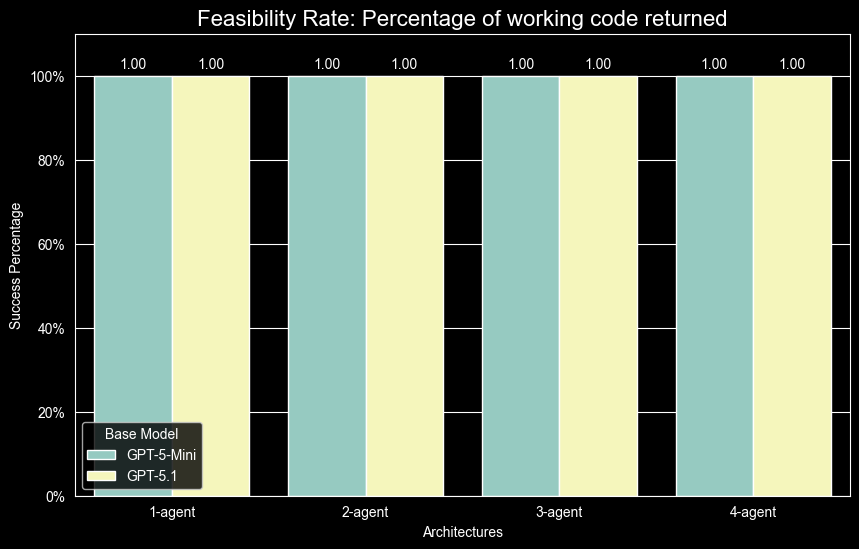

In [11]:

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df,
    x='architecture',
    y='is_success',
    hue='model',
    # palette="viridis",
    errorbar=None
)

ax.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.title('Feasibility Rate: Percentage of working code returned', fontsize=16)
plt.ylabel('Success Percentage')
plt.xlabel('Architectures')
plt.legend(title='Base Model')
plt.ylim(0, 1.1)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.show()

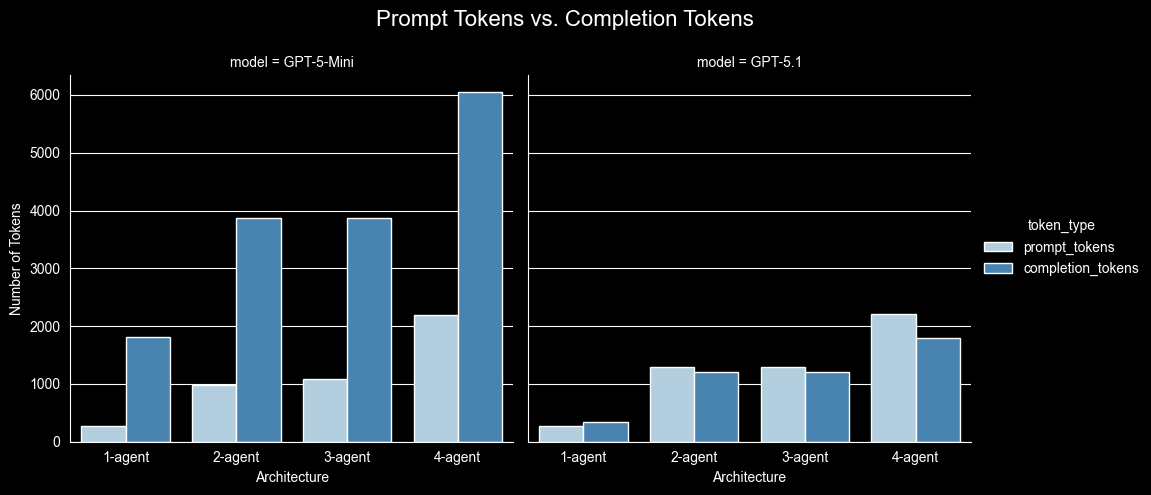

In [12]:
# --- Token Usage ---

df_tokens = df.melt(
    id_vars=['architecture', 'model'],
    value_vars=['prompt_tokens', 'completion_tokens'],
    var_name='token_type',
    value_name='count'
)

g = sns.catplot(
    data=df_tokens,
    kind="bar",
    x="architecture",
    y="count",
    hue="token_type",
    col="model",
    palette="Blues",
    height=5,
    aspect=1,
    errorbar=None
)

# Tutaj completion tokens oznacza liczbę tokenów potrzebnych do wygenerowania odpowiedzi
g.figure.subplots_adjust(top=0.85)
g.figure.suptitle('Prompt Tokens vs. Completion Tokens', fontsize=16)
g.set_axis_labels("Architecture", "Number of Tokens")
plt.show()

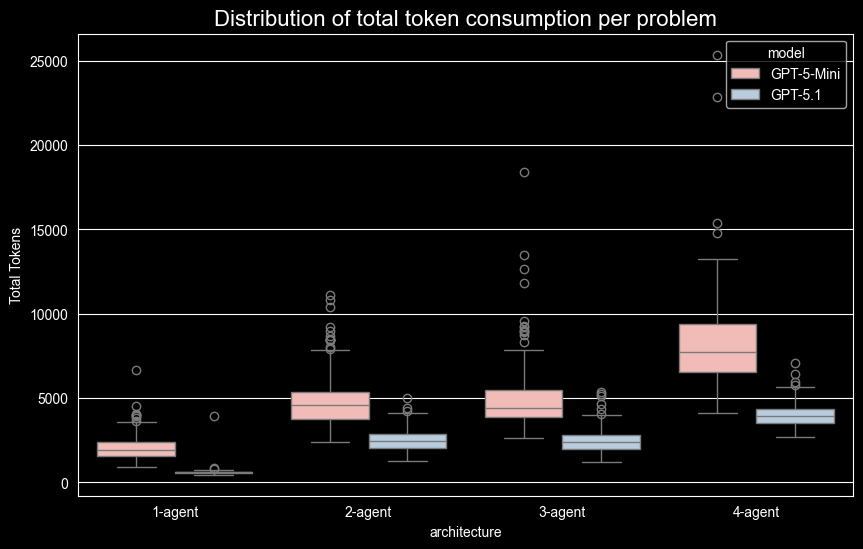

In [13]:
# --- Total Tokens Cost ---
# Boxplot pokazuje rozrzut - czy czasami agenci wpadają w pętlę i zużywają mnóstwo tokenów?

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='architecture',
    y='total_tokens',
    hue='model',
    palette="Pastel1"
)

plt.title('Distribution of total token consumption per problem', fontsize=16)
plt.ylabel('Total Tokens')
plt.show()

In [14]:
# --- Total Token Used for experiments per model---
def calculate_cost(row):
    model_name = row['model']
    prices = MODELS_PRICING[model_name]

    # Cost = (Tokens used / 1,000,000) * Price
    cost_input = (row['prompt_tokens'] / 1_000_000) * prices['input_price']
    cost_output = (row['completion_tokens'] / 1_000_000) * prices['output_price']

    return cost_input + cost_output

In [15]:
df['cost_usd'] = df.apply(calculate_cost, axis=1)
total_cost = df['cost_usd'].sum()
cost_by_model = df.groupby('model')['cost_usd'].sum()

print(f"TOTAL EXPERIMENT COST: ${total_cost:.4f}")
print("-" * 40)
print("Cost per base model:")
print(cost_by_model)

print("-" * 40)
print("Avg cost of single problem (per architecture):")
avg_cost_table = df.groupby(['model', 'architecture'])['cost_usd'].mean().reset_index()
print(avg_cost_table)

TOTAL EXPERIMENT COST: $16.8102
----------------------------------------
Cost per base model:
model
GPT-5-Mini     6.450547
GPT-5.1       10.359685
Name: cost_usd, dtype: float64
----------------------------------------
Avg cost of single problem (per architecture):
        model architecture  cost_usd
0  GPT-5-Mini      1-agent  0.003696
1  GPT-5-Mini      2-agent  0.007976
2  GPT-5-Mini      3-agent  0.008009
3  GPT-5-Mini      4-agent  0.012634
4     GPT-5.1      1-agent  0.003725
5     GPT-5.1      2-agent  0.013757
6     GPT-5.1      3-agent  0.013653
7     GPT-5.1      4-agent  0.020662


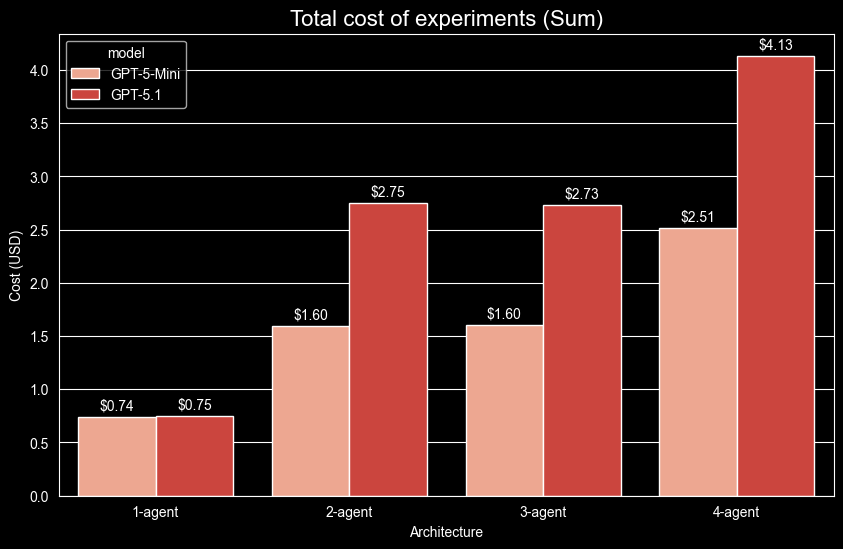

In [16]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x='architecture',
    y='cost_usd',
    hue='model',
    estimator='sum',
    errorbar=None,
    palette="Reds"
)

plt.title('Total cost of experiments (Sum)', fontsize=16)
plt.ylabel('Cost (USD)')
plt.xlabel('Architecture')

ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='$%.2f', padding=3)

plt.show()

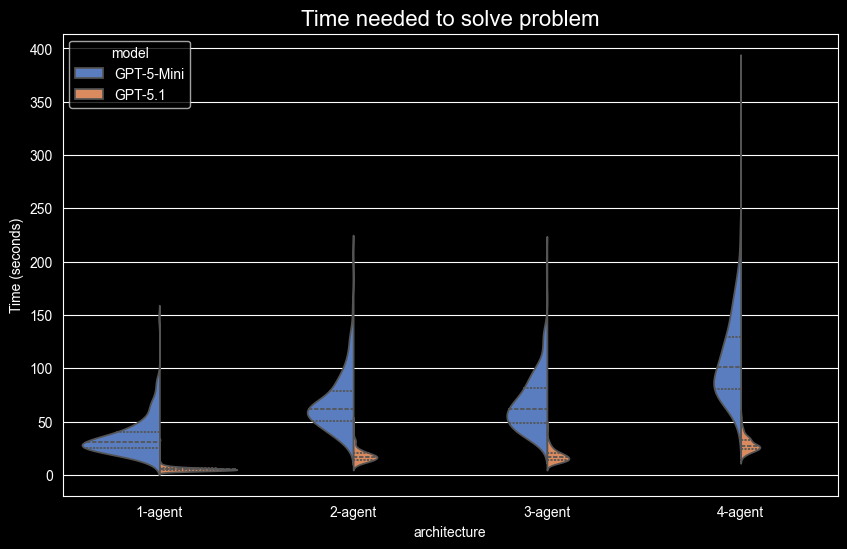

In [17]:
# --- Total Response Latency ---

plt.figure(figsize=(10, 6))
Ssns.violinplot(
    data=df[df['is_success'] == 1],
    x='architecture',
    y='latency_sec',
    hue='model',
    split=True,
    inner="quart",
    palette="muted"
)

plt.title('Time needed to solve problem', fontsize=16)
plt.ylabel('Time (seconds)')
plt.show()

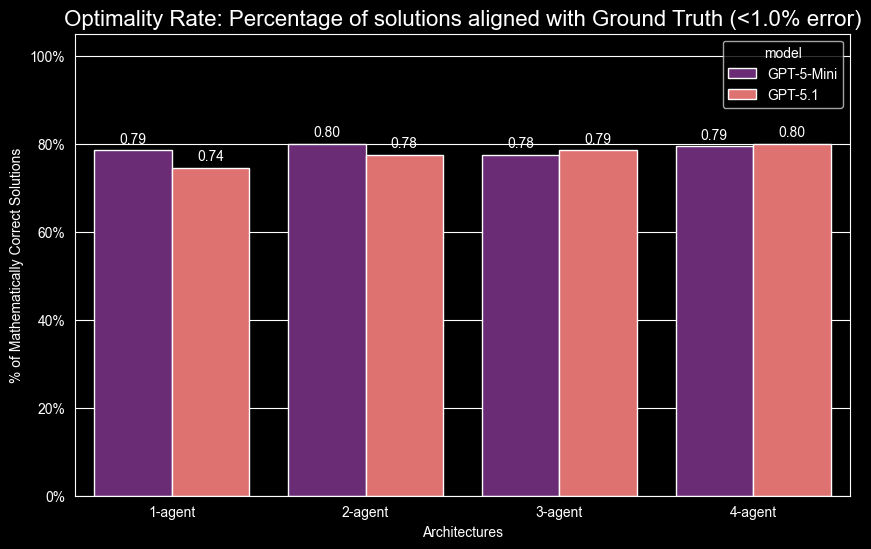

In [20]:
# --- Optimality Rate (Percentage of correct answers) ---
# W zależności od wcześniej zdefiniowanego progu

opt_summary = df.groupby(['model', 'architecture'])['is_optimal'].mean().reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=opt_summary,
    x='architecture',
    y='is_optimal',
    hue='model',
    palette="magma"
)

ax.yaxis.set_major_formatter(PercentFormatter(1.0))
plt.title(f'Optimality Rate: Percentage of solutions aligned with Ground Truth (<{OPTIMALITY_THRESHOLD*100}% error)', fontsize=16)
plt.ylabel('% of Mathematically Correct Solutions')
plt.xlabel('Architectures')
plt.ylim(0, 1.05)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.show()

In [19]:
summary_table = df.groupby(['model', 'architecture']).agg({
    'is_success': 'mean',          # Feasibility Rate
    'is_optimal': 'mean',          # Optimality Rate
    'latency_sec': 'mean',         # Avg Time
    'cost_usd': 'mean',            # Avg cost in $
    'total_tokens': 'mean',        # Avg Tokens
}).reset_index()

summary_table.columns = [
    'Model', 'Architecture',
    'Feasibility', 'Optimality',
    'Avg Time (s)', 'Avg Cost ($)',
    'Avg Tokens'
]

display_table = summary_table.style.format({
    'Feasibility': '{:.1%}',
    'Optimality': '{:.1%}',
    'Avg Time (s)': '{:.2f}',
    'Avg Cost ($)': '${:.4f}',
    'Avg Tokens': '{:.0f}',
    'Median Error': '{:.4f}'
}).background_gradient(subset=['Optimality'], cmap='Greens') \
  .background_gradient(subset=['Avg Cost ($)'], cmap='Reds') # Im drożej tym bardziej czerwono

display_table

,Model,Architecture,Feasibility,Optimality,Avg Time (s),Avg Cost ($),Avg Tokens
0,GPT-5-Mini,1-agent,100.0%,78.5%,35.45,$0.0037,2084
1,GPT-5-Mini,2-agent,100.0%,80.0%,67.62,$0.0080,4853
2,GPT-5-Mini,3-agent,100.0%,77.5%,67.58,$0.0080,4950
3,GPT-5-Mini,4-agent,100.0%,79.4%,110.57,$0.0126,8239
4,GPT-5.1,1-agent,100.0%,74.5%,5.52,$0.0037,617
5,GPT-5.1,2-agent,100.0%,77.5%,18.16,$0.0138,2514
6,GPT-5.1,3-agent,100.0%,78.5%,18.29,$0.0137,2501
7,GPT-5.1,4-agent,100.0%,80.0%,29.05,$0.0207,4006
